In [3]:
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv("Vehicle_Sales.csv")

In [3]:
df.shape

(186, 6)

Вивести 22+7 перших та 5*22-3 останніх записів. 

In [4]:
df[29:107]

,Year,Month,New,Used,Total Sales New,Total Sales Used
29,2004,JUN,42758,65073,$1038212129,$486125865
30,2004,JUL,38329,60994,$958264422,$474975823
31,2004,AUG,37175,61106,$950681015,$470372767
32,2004,SEP,38712,60238,$1004251102,$478484210
33,2004,OCT,34839,57046,$913403542,$452470718
...,...,...,...,...,...,...
102,2010,JUL,23136,54934,$644471700,$457619574
103,2010,AUG,23512,57005,$659524567,$460747955
104,2010,SEP,24520,54371,$692681798,$452201494
105,2010,OCT,22003,50911,$629304220,$423489578


In [5]:
df.dtypes

Year                 int64
Month               object
New                  int64
Used                 int64
Total Sales New     object
Total Sales Used    object
dtype: object

In [5]:

df["Total Sales New"] = df["Total Sales New"].replace("[$,]", "", regex=True ).astype(int)
df["Total Sales Used"] = df["Total Sales Used"].replace("[$,]", "", regex=True ).astype(int)

df.dtypes

Year                 int64
Month               object
New                  int64
Used                 int64
Total Sales New      int64
Total Sales Used     int64
dtype: object

Сумарний обсяг продаж (нових + б/в)

In [21]:
df["Total Sales"] = df["New"] + df["Used"]

df.groupby("Year")[["Total Sales"]].sum()

,Total Sales
Year,
2002,1058253
2003,1103610
2004,1128185
2005,1125669
2006,1096250
2007,1056733
2008,927044
2009,857817
2010,894067


Сумарний дохід від продажу авто  

In [22]:
df["Total Revenue"] = df["Total Sales New"] + df["Total Sales Used"]

df.groupby("Year")[["Total Revenue"]].sum()

,Total Revenue
Year,
2002,14512764648
2003,15789219836
2004,16358504971
2005,16646537437
2006,16277344524
2007,15792131352
2008,12871569827
2009,11196258441
2010,12515717825


Різниця в обсязі продаж нових та б/в авто

In [23]:
df["Sales Difference"] =  df["Used"] - df["New"]

df.groupby("Year")[["Sales Difference"]].sum()

,Sales Difference
Year,
2002,253925
2003,247106
2004,271169
2005,282001
2006,297686
2007,300365
2008,308726
2009,359961
2010,358023


In [24]:
new_order = ["Year", "Month", "Total Revenue", "Total Sales New", "Total Sales Used", "Total Sales", "New", "Used", "Sales Difference"]
df[new_order]

,Year,Month,Total Revenue,Total Sales New,Total Sales Used,Total Sales,New,Used,Sales Difference
0,2002,JAN,1141497749,755015820,386481929,81033,31106,49927,18821
1,2002,FEB,1025807465,664454223,361353242,78502,27520,50982,23462
2,2002,MAR,1225051631,805666244,419385387,93019,34225,58794,24569
3,2002,APR,1279429447,846368297,433061150,96269,36452,59817,23365
4,2002,MAY,1297575194,855005784,442569410,97936,37359,60577,23218
...,...,...,...,...,...,...,...,...,...
181,2017,FEB,1368477237,776222008,592255229,78402,22413,55989,33576
182,2017,MAR,1671449437,926703144,744746293,100555,27838,72717,44879
183,2017,APR,1522703906,867722291,654981615,88875,26135,62740,36605
184,2017,MAY,1656493151,937804113,718689038,97227,28931,68296,39365


Рік та місяць, у які нових автомобілів було продано менше за б/в (8.1)

In [25]:
filtered_df = df[df["New"] < df["Used"]]

filtered_df[["Year", "Month"]]

,Year,Month
0,2002,JAN
1,2002,FEB
2,2002,MAR
3,2002,APR
4,2002,MAY
...,...,...
181,2017,FEB
182,2017,MAR
183,2017,APR
184,2017,MAY


Рік та місяць, коли сумарний дохід був мінімальним; 

In [26]:
min_revenue= df[df["Total Revenue"] == df["Total Revenue"].min()]
min_revenue[["Year", "Month", "Total Revenue"]]


,Year,Month,Total Revenue
97,2010,FEB,701892920


In [ ]:
Рік та місяць, коли було продано найбільше б/в авто. 

In [28]:
max_Used = df[df["Used"] == df["Used"].max()]
max_Used[["Year", "Month", "Used"]]

,Year,Month,Used
170,2016,MAR,73163


Середній дохід від продажу б/в транспортних засобів в місяці 22

In [29]:
month = df.loc[22, "Month"]
year = df.loc[22, "Year"]
average_revenue_used = df.loc[22, "Total Sales Used"] / df.loc[22, "Used"]

f" {year}, {month}, Середній дохід від продажу б/в авто: {average_revenue_used}"



' 2003, NOV, Середній дохід від продажу б/в авто: 7603.684986674563'

Побудувати стовпчикову діаграму обсягу продаж нових авто у році 2012

<Axes: xlabel='Month'>

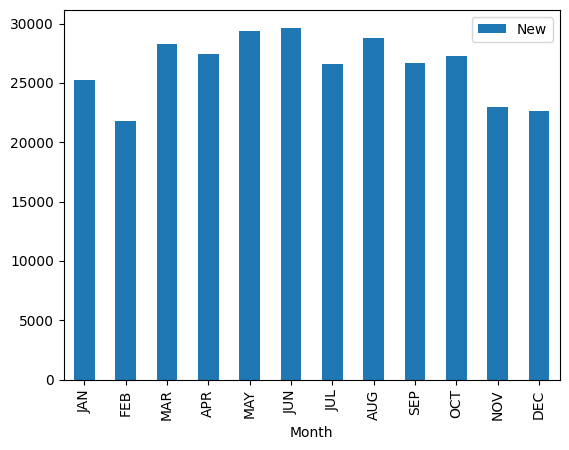

In [30]:
df_2012 = df[df["Year"] == 2012]  
df_2012.plot( x="Month", y= "New", kind= "bar")


Побудувати кругову діаграму сумарного обсягу продаж за кожен рік

<Axes: ylabel='Total Sales'>

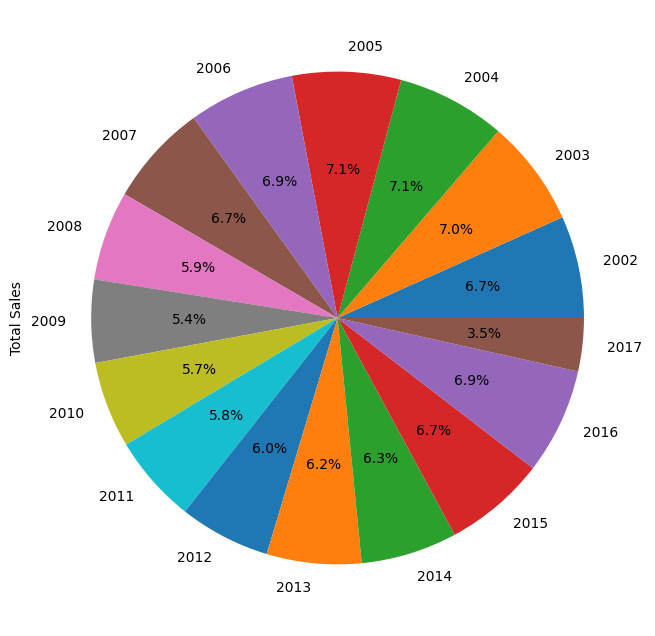

In [31]:
df_grouped = df.groupby("Year")["Total Sales"].sum() 
df_grouped.plot(kind="pie", autopct='%1.1f%%', figsize=(8, 8))

Побудувати на одному графіку:
a. Сумарний дохід від продажу нових авто;
b. Сумарний дохід від продажу старих авто

<BarContainer object of 2 artists>

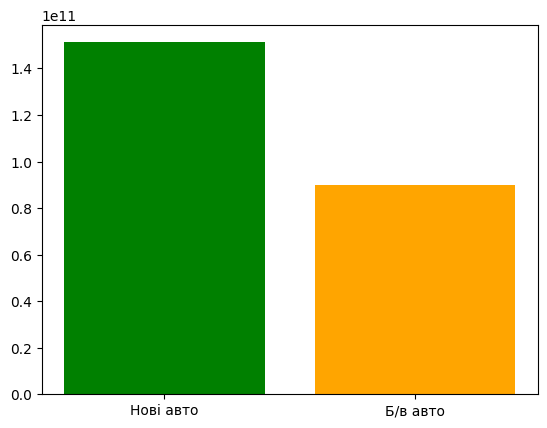

In [32]:
total_sales_new = df["Total Sales New"].sum()
total_sales_used = df["Total Sales Used"].sum()


x = (["Нові авто", "Б/в авто"])
y = ([total_sales_new, total_sales_used])
colors = ["green", "orange"]
plt.bar(x,y, color=colors)